In [8]:
# ==============================================================================
# CELDA 1: CARGA, CRUCE DE IMÁGENES Y BARRIDO DE SENSIBILIDAD DEMOGRÁFICA
# ==============================================================================
import os, glob, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu, ks_2samp

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", context="paper", font_scale=1.2)

DIR_EDA = './graficos_eda/'
os.makedirs(DIR_EDA, exist_ok=True)

# 1. CARGA DEL EXCEL (SIN BORRAR NULOS TODAVÍA)
PATH_IMGS = "/kaggle/input/datasets/ninadaithal/imagesoasis"
EXCEL_FILES = glob.glob("/kaggle/input/**/*.xlsx", recursive=True)
df_demog = pd.read_excel(EXCEL_FILES[0])
df_demog['id_paciente'] = df_demog['ID'].str.extract(r'(OAS1_\d{4})')
df_demog = df_demog.drop_duplicates(subset=['id_paciente'], keep='first')

# 2. CRUCE CON IMÁGENES REALES EN DISCO
valid_ids = set()
if os.path.exists(PATH_IMGS):
    for root, _, files in os.walk(PATH_IMGS):
        for f in files:
            if f.lower().endswith(('.png', '.jpg')):
                match = re.search(r"OAS1_\d{4}", f, re.IGNORECASE)
                if match: valid_ids.add(match.group(0).upper())

df_pacientes = df_demog[df_demog['id_paciente'].isin(valid_ids)].copy()

# TRUCO ORIGINAL: Al hacer > 0, los NaN se evalúan como False (0 = Sano) 
# Esto mantiene a los jóvenes en el dataset para demostrar el sesgo en el barrido.
df_pacientes['etiqueta_medica'] = (df_pacientes['CDR'] > 0).astype(int)

# 3. BARRIDO DE SENSIBILIDAD DEMOGRÁFICA EXACTO
print("📊 INICIANDO BARRIDO DE SENSIBILIDAD DEMOGRÁFICA (EDAD)\n")
print("-" * 105)
print(f"{'Umbral':<18} | {'N (Sanos/Enf)':<15} | {'T-Welch (p)':<17} | {'Mann-Whitney (p)':<17} | {'KS-Test (p)':<15}")
print("-" * 105)

umbrales_edad = [0, 40, 45] + list(range(50, 61)) + [61, 62, 65, 70]
etiquetas_filtro = [f"Edad >= {u}" if u > 0 else "Población Total" for u in umbrales_edad]

def format_p(p):
    if p < 0.001: return f"{p:.4f} ***"
    elif p < 0.01: return f"{p:.4f} **"
    elif p < 0.05: return f"{p:.4f} *"
    else: return f"{p:.4f} (ns)"

for umbral, etiqueta_nombre in zip(umbrales_edad, etiquetas_filtro):
    df_filtrado = df_pacientes[df_pacientes['Age'] >= umbral]
    
    edad_sanos = df_filtrado[df_filtrado['etiqueta_medica'] == 0]['Age'].values
    edad_enfermos = df_filtrado[df_filtrado['etiqueta_medica'] == 1]['Age'].values
    
    n_sanos = len(edad_sanos)
    n_enfermos = len(edad_enfermos)
    str_n = f"{n_sanos} / {n_enfermos}"
    
    if n_sanos < 5 or n_enfermos < 5: continue
        
    _, p_welch = ttest_ind(edad_sanos, edad_enfermos, equal_var=False)
    _, p_mw = mannwhitneyu(edad_sanos, edad_enfermos, alternative='two-sided')
    _, p_ks = ks_2samp(edad_sanos, edad_enfermos)
        
    print(f"{etiqueta_nombre:<18} | {str_n:<15} | {format_p(p_welch):<17} | {format_p(p_mw):<17} | {format_p(p_ks):<15}")

print("-" * 105)

📊 INICIANDO BARRIDO DE SENSIBILIDAD DEMOGRÁFICA (EDAD)

---------------------------------------------------------------------------------------------------------
Umbral             | N (Sanos/Enf)   | T-Welch (p)       | Mann-Whitney (p)  | KS-Test (p)    
---------------------------------------------------------------------------------------------------------
Población Total    | 266 / 81        | 0.0000 ***        | 0.0000 ***        | 0.0000 ***     
Edad >= 40         | 141 / 81        | 0.0000 ***        | 0.0000 ***        | 0.0000 ***     
Edad >= 45         | 131 / 81        | 0.0000 ***        | 0.0000 ***        | 0.0000 ***     
Edad >= 50         | 111 / 81        | 0.0001 ***        | 0.0026 **         | 0.0009 ***     
Edad >= 51         | 107 / 81        | 0.0009 ***        | 0.0078 **         | 0.0037 **      
Edad >= 52         | 104 / 81        | 0.0033 **         | 0.0171 *          | 0.0099 **      
Edad >= 53         | 102 / 81        | 0.0074 **         | 0.0283 *

In [9]:
# ==============================================================================
# CELDA 2: INFORMACIÓN PARA TABLAS LATEX (CONSOLIDACIÓN N=172)
# ==============================================================================
# AHORA SÍ: Aplicamos los filtros estrictos para la población de entrenamiento
df_consolidado = df_pacientes[(df_pacientes['Age'] >= 56) & (df_pacientes['CDR'].notna())].copy()

# Categorizaciones
df_consolidado['Diagnostico'] = np.where(df_consolidado['CDR'] == 0, 'Sano', 
                                  np.where(df_consolidado['CDR'] == 0.5, 'MCI', 'Alzheimer/Demencia'))
df_consolidado['Clase_Binaria'] = np.where(df_consolidado['CDR'] > 0, 'Enfermo', 'Sano')

df_consolidado['Franja_Edad'] = pd.cut(df_consolidado['Age'], bins=[55, 65, 75, 85, 120], 
                                 labels=['56-65 años', '66-75 años', '76-85 años', '86+ años'])

print("=========================================================")
print(f"✅ POBLACIÓN DEFINITIVA CONSOLIDADA: N={len(df_consolidado)} pacientes")
print("=========================================================\n")

print("▶ DATOS PARA LA TABLA 1 (MULTICLASE POR ESTADIO Y EDAD)")
totales_multi = df_consolidado['CDR'].value_counts().sort_index()
for cdr, count in totales_multi.items():
    print(f"CDR {cdr}: {count} pacientes ({(count/len(df_consolidado))*100:.1f}%)")

print("\nMatriz Edad vs Diagnóstico (Sano / MCI / Alzheimer-Demencia):")
tabla_edad_multi = pd.crosstab(df_consolidado['Franja_Edad'], df_consolidado['Diagnostico'], margins=True, margins_name='Total')
print(tabla_edad_multi[['Sano', 'MCI', 'Alzheimer/Demencia', 'Total']])

print("\n\n▶ DATOS PARA LA TABLA 2 (BINARIA SANO VS ENFERMO)")
totales_bin = df_consolidado['Clase_Binaria'].value_counts()
for clase, count in totales_bin.items():
    print(f"{clase}: {count} pacientes ({(count/len(df_consolidado))*100:.1f}%)")

print("\nMatriz Edad vs Sano/Enfermo:")
tabla_edad_bin = pd.crosstab(df_consolidado['Franja_Edad'], df_consolidado['Clase_Binaria'], margins=True, margins_name='Total')
print(tabla_edad_bin[['Sano', 'Enfermo', 'Total']])

✅ POBLACIÓN DEFINITIVA CONSOLIDADA: N=172 pacientes

▶ DATOS PARA LA TABLA 1 (MULTICLASE POR ESTADIO Y EDAD)
CDR 0.0: 91 pacientes (52.9%)
CDR 0.5: 58 pacientes (33.7%)
CDR 1.0: 21 pacientes (12.2%)
CDR 2.0: 2 pacientes (1.2%)

Matriz Edad vs Diagnóstico (Sano / MCI / Alzheimer-Demencia):
Diagnostico  Sano  MCI  Alzheimer/Demencia  Total
Franja_Edad                                      
56-65 años     18    4                   1     23
66-75 años     33   23                   7     63
76-85 años     22   27                  10     59
86+ años       18    4                   5     27
Total          91   58                  23    172


▶ DATOS PARA LA TABLA 2 (BINARIA SANO VS ENFERMO)
Sano: 91 pacientes (52.9%)
Enfermo: 81 pacientes (47.1%)

Matriz Edad vs Sano/Enfermo:
Clase_Binaria  Sano  Enfermo  Total
Franja_Edad                        
56-65 años       18        5     23
66-75 años       33       30     63
76-85 años       22       37     59
86+ años         18        9     27
Total

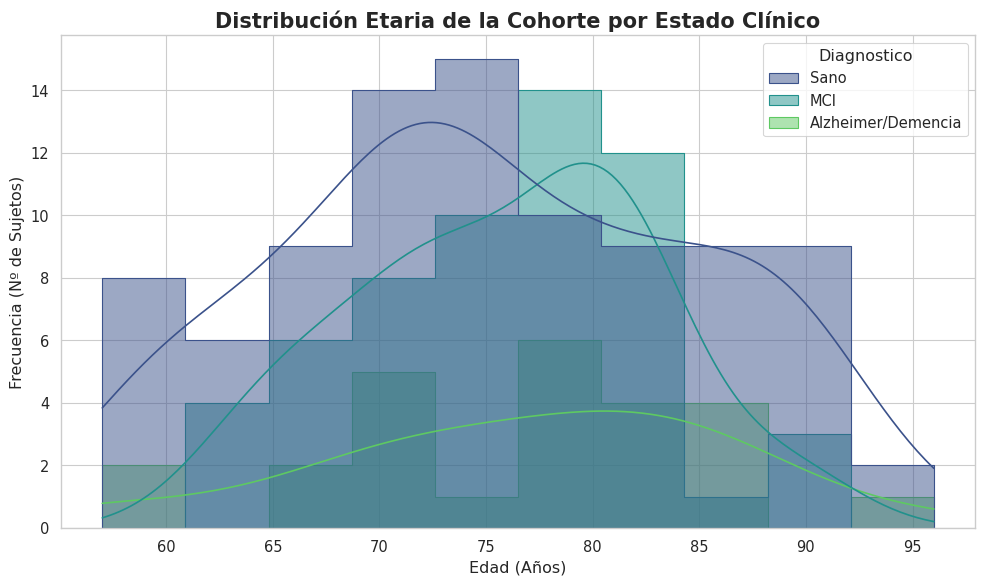

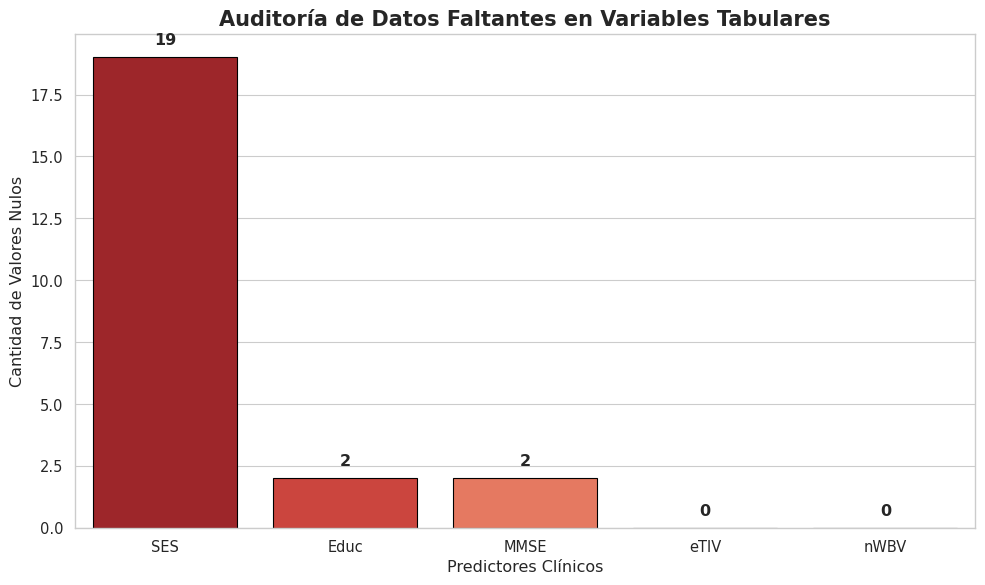

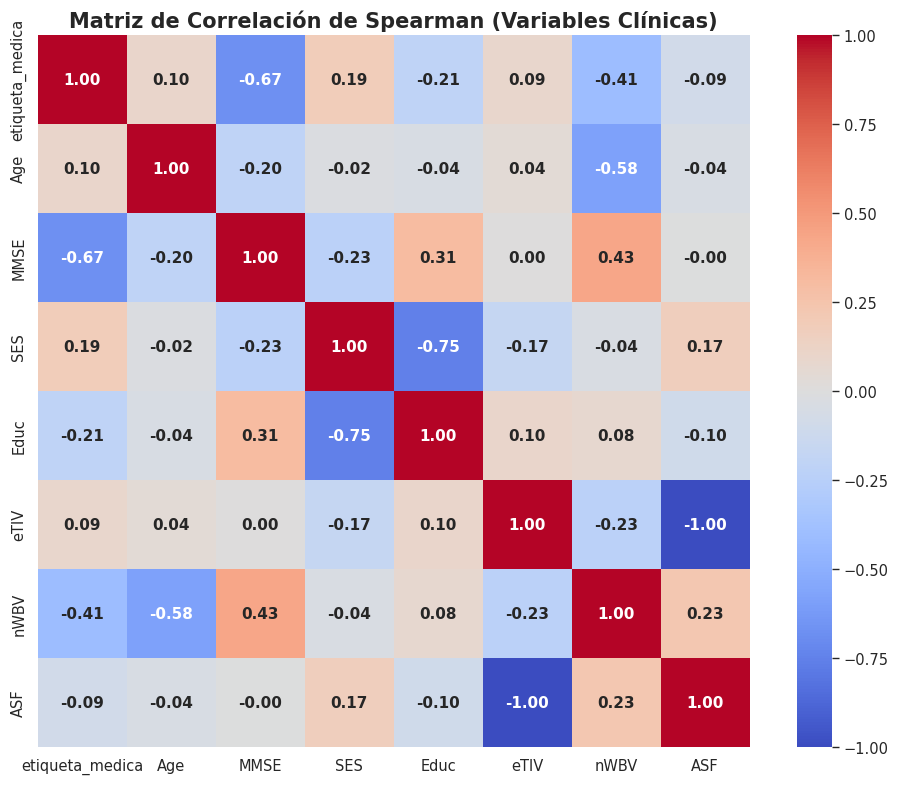

✅ ¡ÉXITO! Las 3 gráficas han sido restauradas y guardadas en './graficos_eda/'


In [10]:
# ==============================================================================
# CELDA 3: BATERÍA DE 3 GRÁFICOS (Histograma, Nulos, Correlación)
# ==============================================================================

# Para el EDA usamos Age >= 56 SIN purgar CDR todavía (para que salgan los 21 nulos de SES)
df_eda = df_pacientes[df_pacientes['Age'] >= 56].copy()
df_eda['Diagnostico'] = np.where(df_eda['CDR'] == 0, 'Sano', 
                        np.where(df_eda['CDR'] == 0.5, 'MCI', 'Alzheimer/Demencia'))

# ----------------- 1. HISTOGRAMA DE EDADES -----------------
plt.figure(figsize=(10, 6))
sns.histplot(data=df_eda, x='Age', hue='Diagnostico', kde=True, element="step", palette="viridis", alpha=0.5)

plt.title('Distribución Etaria de la Cohorte por Estado Clínico', fontsize=15, fontweight='bold')
plt.xlabel('Edad (Años)')
plt.ylabel('Frecuencia (Nº de Sujetos)')
plt.tight_layout()
plt.savefig(os.path.join(DIR_EDA, 'Histograma_Edades.png'), dpi=300, bbox_inches='tight')
plt.show()

# ----------------- 2. AUDITORÍA DE NULOS -----------------
plt.figure(figsize=(10, 6))
nulos = df_eda[['Educ', 'SES', 'MMSE', 'eTIV', 'nWBV']].isnull().sum()
nulos = nulos.sort_values(ascending=False)

sns.barplot(x=nulos.index, y=nulos.values, palette="Reds_r", edgecolor='black')

for i, v in enumerate(nulos.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.title('Auditoría de Datos Faltantes en Variables Tabulares', fontsize=15, fontweight='bold')
plt.ylabel('Cantidad de Valores Nulos')
plt.xlabel('Predictores Clínicos')
plt.tight_layout()
plt.savefig(os.path.join(DIR_EDA, 'Auditoria_Nulos.png'), dpi=300, bbox_inches='tight')
plt.show()

# ----------------- 3. MATRIZ DE CORRELACIÓN DE SPEARMAN -----------------
plt.figure(figsize=(10, 8))
cols_corr = ['etiqueta_medica', 'Age', 'MMSE', 'SES', 'Educ', 'eTIV', 'nWBV', 'ASF']

corr_matrix = df_eda[cols_corr].corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
            center=0, square=True, annot_kws={"weight": "bold", "size": 11})

plt.title('Matriz de Correlación de Spearman (Variables Clínicas)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIR_EDA, 'Matriz_Correlacion.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ¡ÉXITO! Las 3 gráficas han sido restauradas y guardadas en '{DIR_EDA}'")